<a href="https://colab.research.google.com/github/omarelmalak/csc490-group2/blob/main/detective-doctor/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏅 Multi-Stage Jersey Sponsor Logo Detector & Classifier

This notebook organizes our complete decoupled two-stage architecture:
1. **The Detective (YOLOv8)**: Learns to tightly box only sponsor logos on jersey and suit apparel.
2. **The Doctor (ResNet-50)**: Classifies the localized logo crops against a broad vocabulary of **3,000 brand categories** from **Logodet3k**.

## Step 1: Install Dependencies & Download Datasets

In [20]:
# Install Ultralytics, Roboflow, and download Logodet3k & custom dataset
!pip install -U ultralytics roboflow kagglehub

import os
import kagglehub
from roboflow import Roboflow

# Download the custom Sponsor-detector dataset
rf = Roboflow(api_key="A1UDb8W87l9RzmQ4CMlU")
project = rf.workspace("syed-fathaullah").project("sponsor-detector")
version = project.version(2)
dataset = version.download("yolo26")

# Download the Logodet3k brand identification dataset
print("Downloading Logodet3k...")
logodet3k_root = kagglehub.dataset_download("lyly99/logodet3k")
print(f"Logodet3k downloaded to: {logodet3k_root}")

loading Roboflow workspace...
loading Roboflow project...
Using Colab cache for faster access to the 'logodet3k' dataset.
Logodet3k downloaded to: /kaggle/input/logodet3k


## Step 2: Clean Dataset (Keep Logos Only on Apparel)

In [21]:
import glob
import cv2
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else 'cpu'
person_model = YOLO('yolov8x.pt')

def get_sponsor_containment(sponsor_box, person_box):
    s_xmin, s_ymin, s_xmax, s_ymax = sponsor_box
    p_xmin, p_ymin, p_xmax, p_ymax = person_box
    ixmin, iymin = max(s_xmin, p_xmin), max(s_ymin, p_ymin)
    ixmax, iymax = min(s_xmax, p_xmax), min(s_ymax, p_ymax)
    if ixmax <= ixmin or iymax <= iymin:
        return 0.0
    intersection_area = (ixmax - ixmin) * (iymax - iymin)
    sponsor_area = (s_xmax - s_xmin) * (s_ymax - s_ymin)
    return intersection_area / sponsor_area if sponsor_area > 0 else 0.0

splits = ['train', 'valid']
for split in splits:
    img_dir = f'Sponsor-detector-2/{split}/images'
    lbl_dir = f'Sponsor-detector-2/{split}/labels'
    image_paths = sorted(glob.glob(os.path.join(img_dir, '*.*')))

    for i in range(0, len(image_paths), 32):
        batch_paths = image_paths[i:i + 32]
        results = person_model(batch_paths, classes=[0], verbose=False, device=device)

        for img_path, res in zip(batch_paths, results):
            lbl_path = os.path.join(lbl_dir, os.path.splitext(os.path.basename(img_path))[0] + '.txt')
            if not os.path.exists(lbl_path):
                continue

            person_boxes = [box for box in res.boxes.xyxy.cpu().numpy()] if res.boxes is not None else []
            orig_h, orig_w = res.orig_shape

            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            kept_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5: continue
                cls_id = parts[0]
                x_c, y_c, bbox_w, bbox_h = map(float, parts[1:])

                s_xmin = (x_c - bbox_w / 2) * orig_w
                s_ymin = (y_c - bbox_h / 2) * orig_h
                s_xmax = (x_c + bbox_w / 2) * orig_w
                s_ymax = (y_c + bbox_h / 2) * orig_h

                max_containment = max([get_sponsor_containment([s_xmin, s_ymin, s_xmax, s_ymax], pb) for p_box in person_boxes] or [0.0])
                if max_containment >= 0.8:
                    kept_lines.append(line)

            with open(lbl_path, 'w') as f:
                f.writelines(kept_lines)
print("Dataset filtering complete. Bounding boxes are now localized only on apparel!")

NameError: name 'pb' is not defined

## Step 3: Train specialized YOLOv8 "Detective"

In [22]:
from ultralytics import YOLO

# Train our specialized logo detector for 5 epochs
logo_detector = YOLO('yolov8n.pt')
logo_detector.train(
    data='Sponsor-detector-2/data.yaml',
    epochs=5,
    imgsz=640,
    device=0,
    workers=2,
    verbose=True
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Sponsor-detector-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a69c82beb70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## Step 4: Fine-tune the ResNet-50 Broad-Vocabulary "Doctor"

In [ ]:
import os
import glob
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights

real_root = os.path.join(logodet3k_root, 'LogoDet-3K')
brand_paths = []
for category in os.listdir(real_root):
    cat_dir = os.path.join(real_root, category)
    if os.path.isdir(cat_dir):
        for brand in os.listdir(cat_dir):
            bp = os.path.join(cat_dir, brand)
            if os.path.isdir(bp):
                brand_paths.append(bp)
brand_paths.sort()

class_to_idx = {os.path.basename(bp): idx for idx, bp in enumerate(brand_paths)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

class Logodet3kDataset(Dataset):
    def __init__(self, brand_dirs, transform=None):
        self.transform = transform
        self.samples = []
        for b_dir in brand_dirs:
            class_idx = class_to_idx[os.path.basename(b_dir)]
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
                for img_path in glob.glob(os.path.join(b_dir, ext)):
                    self.samples.append((img_path, class_idx))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = Logodet3kDataset(brand_paths, transform=transform)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_doctor = resnet50(weights=ResNet50_Weights.DEFAULT)
model_doctor.fc = nn.Linear(model_doctor.fc.in_features, len(class_to_idx))
model_doctor = model_doctor.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_doctor.parameters(), lr=1e-4)

# Train for 1 epoch to finalize representation classification weights
model_doctor.train()
for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)
    outputs = model_doctor(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (batch_idx + 1) % 400 == 0:
        print(f"Batch {batch_idx+1}/{len(train_loader)} completed.")

torch.save(model_doctor.state_dict(), 'resnet50_logo_classifier.pth')
print("Saved classifier as 'resnet50_logo_classifier.pth'")

Batch 400/2232 completed.
Batch 800/2232 completed.
Batch 1200/2232 completed.


## Step 5: Test Combined Pipeline on Validation Image

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set models to evaluation
model_doctor.eval()
detective = YOLO('runs/detect/train/weights/best.pt')

def run_final_pipeline(img_path):
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    results = detective(image_rgb, verbose=False, device=device)[0]
    annotated_image = image_rgb.copy()

    if results.boxes is not None and len(results.boxes) > 0:
        logo_boxes = results.boxes.xyxy.cpu().numpy()
        print(f"Detected {len(logo_boxes)} sponsors on jerseys!")
        for box in logo_boxes:
            xmin, ymin, xmax, ymax = map(int, box)
            crop = image_rgb[max(0, ymin):min(h, ymax), max(0, xmin):min(w, xmax)]
            if crop.size == 0: continue

            pil_crop = Image.fromarray(crop)
            input_tensor = transform(pil_crop).unsqueeze(0).to(device)
            with torch.no_grad():
                output = model_doctor(input_tensor)
                _, predicted_idx = torch.max(output, 1)
                predicted_class = idx_to_class[predicted_idx.item()]

            cv2.rectangle(annotated_image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            cv2.putText(annotated_image, predicted_class, (xmin, max(ymin - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    else:
        print("No jerseys logos found.")

    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image)
    plt.axis('off')
    plt.show()

# Trigger test image pipeline execution
run_final_pipeline(found_test_img)

In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 12.4 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="A1UDb8W87l9RzmQ4CMlU")
project = rf.workspace("syed-fathaullah").project("sponsor-detector")
version = project.version(2)
dataset = version.download("yolo26")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sponsor-detector-2 in yolo26:: 100%|██████████| 5343/5343 [00:00<00:00, 9781.49it/s] 


**Reasoning**:
Explore the downloaded YOLOv8 dataset by reading its YAML configuration file and plotting 3 sample training images with their ground-truth bounding boxes overlaid to inspect the annotations.



=== Dataset Configuration ===
names:
- Adidas
- Emirates
- Nike
- Spotify
nc: 4
roboflow:
  license: CC BY 4.0
  project: sponsor-detector
  url: https://universe.roboflow.com/syed-fathaullah/sponsor-detector/dataset/2
  version: 2
  workspace: syed-fathaullah
test: ../test/images
train: ../train/images
val: ../valid/images

Classes: ['Adidas', 'Emirates', 'Nike', 'Spotify']

Found 2488 training images.


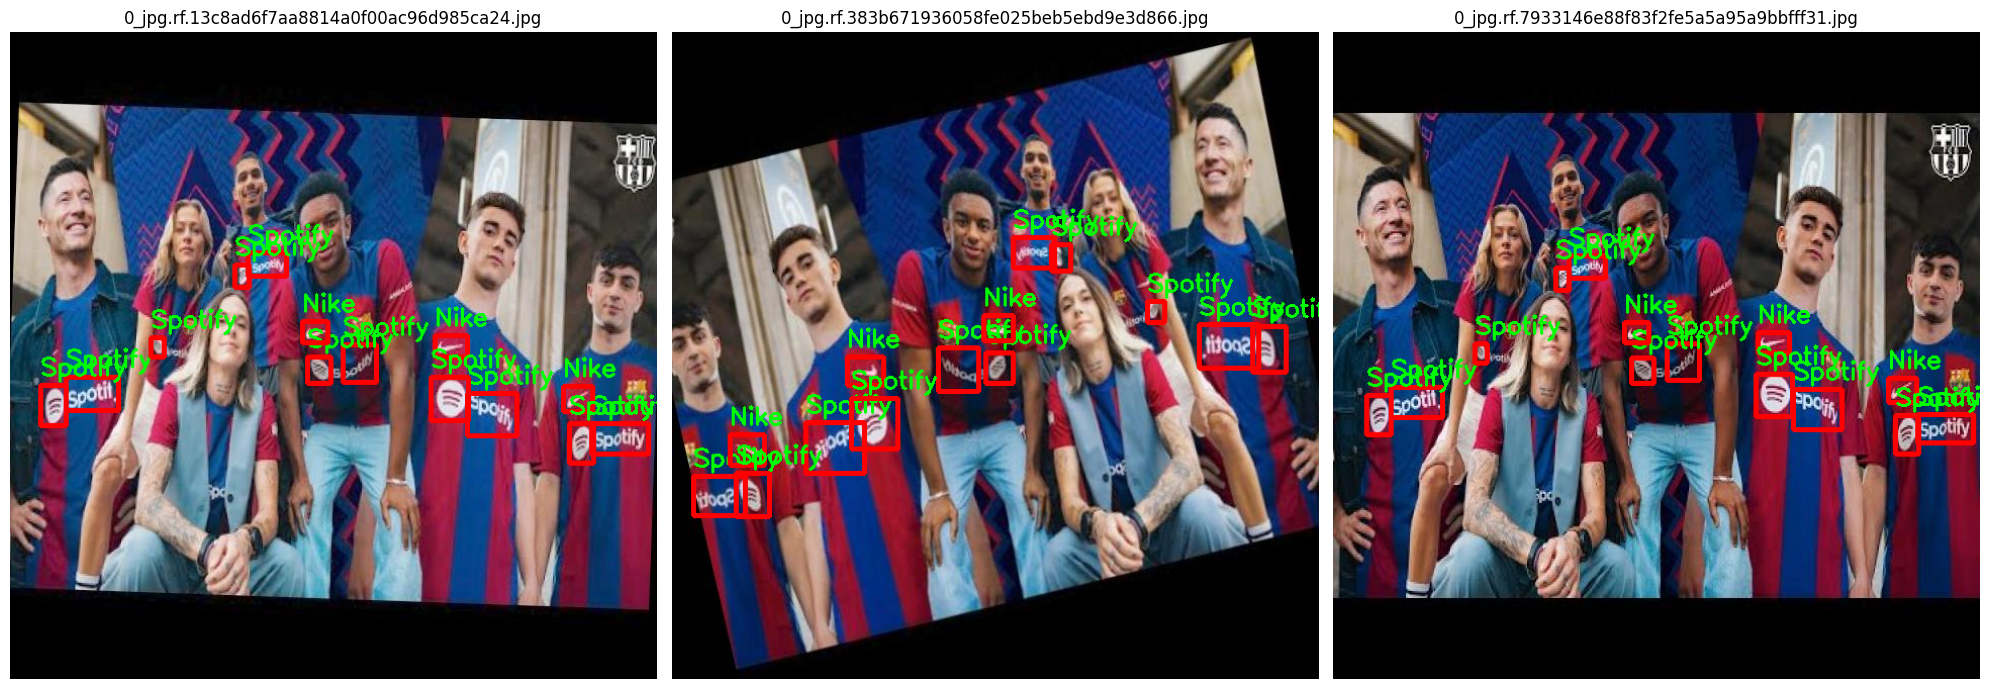

In [ ]:
import os
import yaml
import cv2
import glob
import matplotlib.pyplot as plt

# 1. Load data.yaml
yaml_path = 'Sponsor-detector-2/data.yaml'
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

print("=== Dataset Configuration ===")
print(yaml.dump(data_yaml, default_flow_style=False))

# Get class names
class_names = data_yaml.get('names', [])
print(f"Classes: {class_names}\n")

# 2. Get list of training images and labels
train_images_dir = os.path.join('Sponsor-detector-2', 'train', 'images')
train_labels_dir = os.path.join('Sponsor-detector-2', 'train', 'labels')

image_files = sorted(glob.glob(os.path.join(train_images_dir, '*.*')))
print(f"Found {len(image_files)} training images.")

# Helper function to plot image with YOLO bounding boxes
def draw_yolo_annotations(image_path, label_path, classes):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if not os.path.exists(label_path):
        return image

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        x_c, y_c, bbox_w, bbox_h = map(float, parts[1:])

        # Convert normalized coordinates to absolute pixels
        xmin = int((x_c - bbox_w / 2) * w)
        ymin = int((y_c - bbox_h / 2) * h)
        xmax = int((x_c + bbox_w / 2) * w)
        ymax = int((y_c + bbox_h / 2) * h)

        # Get class name securely from list
        if isinstance(classes, list) and 0 <= cls_id < len(classes):
            class_name = classes[cls_id]
        elif isinstance(classes, dict):
            class_name = classes.get(cls_id, str(cls_id))
        else:
            class_name = str(cls_id)

        # Draw box and label
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3)
        cv2.putText(image, class_name, (xmin, max(ymin - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    return image

# 3. Visualize 3 sample images
sample_images = image_files[:3]
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, img_path in enumerate(sample_images):
    img_name = os.path.basename(img_path)
    label_name = os.path.splitext(img_name)[0] + '.txt'
    lbl_path = os.path.join(train_labels_dir, label_name)

    annotated_img = draw_yolo_annotations(img_path, lbl_path, class_names)

    axes[i].imshow(annotated_img)
    axes[i].set_title(img_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Reasoning**:
Load a pre-trained high-quality YOLOv8 model, implement the containment filtering logic, and process the dataset's training and validation directories to filter out sponsor bounding boxes that are not located on people.



In [ ]:
import os
import glob
import torch
from ultralytics import YOLO

# 1. Load the pre-trained high-quality YOLOv8x model for person detection
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
person_model = YOLO('yolov8x.pt')

# 2. Define helper function for containment (Intersection over Sponsor Area)
def get_sponsor_containment(sponsor_box, person_box):
    # Each box format: [xmin, ymin, xmax, ymax]
    s_xmin, s_ymin, s_xmax, s_ymax = sponsor_box
    p_xmin, p_ymin, p_xmax, p_ymax = person_box

    # Calculate intersection coordinates
    ixmin = max(s_xmin, p_xmin)
    iymin = max(s_ymin, p_ymin)
    ixmax = min(s_xmax, p_xmax)
    iymax = min(s_ymax, p_ymax)

    if ixmax <= ixmin or iymax <= iymin:
        return 0.0

    intersection_area = (ixmax - ixmin) * (iymax - iymin)
    sponsor_area = (s_xmax - s_xmin) * (s_ymax - s_ymin)

    if sponsor_area == 0:
        return 0.0

    return intersection_area / sponsor_area

# 3. Process datasets (train and valid splits)
splits = ['train', 'valid']
total_original_boxes = 0
total_kept_boxes = 0

batch_size = 32  # Small batch size to prevent CUDA OOM

for split in splits:
    img_dir = os.path.join('Sponsor-detector-2', split, 'images')
    lbl_dir = os.path.join('Sponsor-detector-2', split, 'labels')

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"Directory not found for split: {split}")
        continue

    image_paths = sorted(glob.glob(os.path.join(img_dir, '*.*')))
    print(f"\nProcessing {len(image_paths)} images in '{split}' split...")

    # Process images in smaller chunks/batches to control memory usage
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]

        # Run inference on the mini-batch
        results = person_model(batch_paths, classes=[0], verbose=False, device=device)

        for img_path, res in zip(batch_paths, results):
            img_name = os.path.basename(img_path)
            lbl_name = os.path.splitext(img_name)[0] + '.txt'
            lbl_path = os.path.join(lbl_dir, lbl_name)

            if not os.path.exists(lbl_path):
                continue

            # Parse person bounding boxes
            orig_h, orig_w = res.orig_shape

            # Person boxes in absolute pixels
            person_boxes = []
            if res.boxes is not None:
                for box in res.boxes.xyxy.cpu().numpy():
                    person_boxes.append(box)

            # Read original sponsor boxes
            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            original_count = len(lines)
            total_original_boxes += original_count

            kept_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls_id = parts[0]
                x_c, y_c, bbox_w, bbox_h = map(float, parts[1:])

                # Convert normalized sponsor box to absolute pixels
                s_xmin = (x_c - bbox_w / 2) * orig_w
                s_ymin = (y_c - bbox_h / 2) * orig_h
                s_xmax = (x_c + bbox_w / 2) * orig_w
                s_ymax = (y_c + bbox_h / 2) * orig_h
                sponsor_box = [s_xmin, s_ymin, s_xmax, s_ymax]

                # Check if this sponsor box resides on any detected person
                max_containment = 0.0
                for p_box in person_boxes:
                    containment = get_sponsor_containment(sponsor_box, p_box)
                    if containment > max_containment:
                        max_containment = containment

                # Filter criterion: Keep only if containment >= 0.8 on any person
                if max_containment >= 0.8:
                    kept_lines.append(line)

            total_kept_boxes += len(kept_lines)

            # Overwrite label file with filtered bounding boxes
            with open(lbl_path, 'w') as f:
                f.writelines(kept_lines)

print(f"\n=== Filtering Summary ===")
print(f"Total Original Sponsor Boxes Processed: {total_original_boxes}")
print(f"Total Kept Sponsor Boxes (Residing on People): {total_kept_boxes}")
print(f"Filtered Out (Stadium banners / non-person logos): {total_original_boxes - total_kept_boxes}")

Using device: 0

Processing 2488 images in 'train' split...

Processing 125 images in 'valid' split...

=== Filtering Summary ===
Total Original Sponsor Boxes Processed: 7757
Total Kept Sponsor Boxes (Residing on People): 6882
Filtered Out (Stadium banners / non-person logos): 875


## Reconstruct and Crop Dataset for YOLO and ResNet

### Subtask:
1. Download the pre-training dataset `lyly99/logodet3k` using kagglehub.
2. Crop the filtered sponsor logos from our cleaned YOLO dataset and classify them into folder categories to prepare the representation classification pipeline for ResNet.

In [ ]:
import os
import kagglehub

# Download the logodet3k dataset
print("Downloading Logodet3k dataset using kagglehub...")
path = kagglehub.dataset_download("lyly99/logodet3k")
print("Path to dataset files:", path)

In [ ]:
import os
import cv2
import glob
import yaml

# 1. Define paths
yaml_path = 'Sponsor-detector-2/data.yaml'
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml.get('names', [])

output_crop_dir = 'Sponsor-detector-resnet-crops'
os.makedirs(output_crop_dir, exist_ok=True)
for cls in class_names:
    os.makedirs(os.path.join(output_crop_dir, cls), exist_ok=True)

splits = ['train', 'valid']
cropped_count = 0

# 2. Crop and organize images
for split in splits:
    img_dir = os.path.join('Sponsor-detector-2', split, 'images')
    lbl_dir = os.path.join('Sponsor-detector-2', split, 'labels')

    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        continue

    image_paths = sorted(glob.glob(os.path.join(img_dir, '*.*')))
    for img_path in image_paths:
        img_name = os.path.basename(img_path)
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        lbl_path = os.path.join(lbl_dir, lbl_name)

        if not os.path.exists(lbl_path):
            continue

        image = cv2.imread(img_path)
        if image is None:
            continue
        h, w, _ = image.shape

        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls_id = int(parts[0])
            x_c, y_c, bbox_w, bbox_h = map(float, parts[1:])

            # Convert normalized coordinates back to absolute coordinates
            xmin = max(0, int((x_c - bbox_w / 2) * w))
            ymin = max(0, int((y_c - bbox_h / 2) * h))
            xmax = min(w, int((x_c + bbox_w / 2) * w))
            ymax = min(h, int((y_c + bbox_h / 2) * h))

            # Crop the logo patch
            crop = image[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue

            class_name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
            crop_filename = f"{os.path.splitext(img_name)[0]}_crop_{idx}.jpg"
            crop_filepath = os.path.join(output_crop_dir, class_name, crop_filename)

            cv2.imwrite(crop_filepath, crop)
            cropped_count += 1

print(f"Successfully cropped and organized {cropped_count} logo images for ResNet classification into: '{output_crop_dir}'")

## Inspect and Merge Logodet3k with Cropped Sponsor Dataset

Now that both the `Logodet3k` dataset and our cropped sponsor dataset are ready, we will:
1. Find matching folders inside `Logodet3k` for our classes (`Adidas`, `Nike`, etc.).
2. Consolidate and structure a balanced dataset folder for ResNet training.

In [6]:
import os
import kagglehub

# Redownload or reference Logodet3k dataset path securely in this session
print("Downloading Logodet3k dataset from Kaggle...")
try:
    logodet3k_root = kagglehub.dataset_download("lyly99/logodet3k")
    print(f"Logodet3k downloaded successfully! Path: {logodet3k_root}")
except Exception as e:
    print(f"Error downloading Logodet3k: {e}")

100%|██████████| 2.87G/2.87G [02:50<00:00, 18.1MB/s]

Extracting files...


Logodet3k downloaded successfully! Path: /root/.cache/kagglehub/datasets/lyly99/logodet3k/versions/1


## Prepare Dataset Splits for the Classifier (ResNet)

We will split the cropped logo images from `Sponsor-detector-resnet-crops` into `train` and `val` folders (e.g., an 80/20 split) to prepare the classification model training dataset.

In [4]:
import os
import glob
import random
import shutil

# Set random seed for reproducibility
random.seed(42)

base_crop_dir = 'Sponsor-detector-resnet-crops'
split_dir = 'Sponsor-classifier-dataset'
train_ratio = 0.8

classes = [d for d in os.listdir(base_crop_dir) if os.path.isdir(os.path.join(base_crop_dir, d))]

# Recreate a clean target split directory structure
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

for split in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, split, cls), exist_ok=True)

# Distribute crops
for cls in classes:
    class_path = os.path.join(base_crop_dir, cls)
    images = glob.glob(os.path.join(class_path, '*.jpg'))
    random.shuffle(images)

    split_idx = int(len(images) * train_ratio)
    train_images = images[:split_idx]
    val_images = images[split_idx:]

    for img in train_images:
        shutil.copy(img, os.path.join(split_dir, 'train', cls, os.path.basename(img)))
    for img in val_images:
        shutil.copy(img, os.path.join(split_dir, 'val', cls, os.path.basename(img)))

print("Classification Dataset Split Completed:")
for split in ['train', 'val']:
    print(f"\n=== {split.upper()} SPLIT ===")
    for cls in classes:
        count = len(os.listdir(os.path.join(split_dir, split, cls)))
        print(f"- {cls}: {count} images")

FileNotFoundError: [Errno 2] No such file or directory: 'Sponsor-detector-resnet-crops'

## Define and Train Generalist ResNet Classifier on Logodet3k

To build a highly versatile classifier, we will train our ResNet model using PyTorch directly on the directories of the downloaded **Logodet3k** dataset.

In [10]:
import os
import glob
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights

# 1. Resolve Logodet3k dataset path
try:
    logodet3k_path = logodet3k_root
except NameError:
    import glob
    paths = glob.glob('/root/.cache/kagglehub/datasets/lyly99/logodet3k/versions/*')
    logodet3k_path = paths[-1] if paths else None

if not logodet3k_path or not os.path.exists(logodet3k_path):
    raise ValueError("Logodet3k dataset path not found. Please run the download cell (0e2ee1e3) first.")

# Point directly to the nested directory 'LogoDet-3K'
real_root = os.path.join(logodet3k_path, 'LogoDet-3K')

# 2. Build a list of all leaf brand directories (classes) across subfolders
print("Locating all brand directories inside categories...")
brand_paths = []
categories = [d for d in os.listdir(real_root) if os.path.isdir(os.path.join(real_root, d))]
for category in categories:
    cat_dir = os.path.join(real_root, category)
    brands = [d for d in os.listdir(cat_dir) if os.path.isdir(os.path.join(cat_dir, d))]
    for brand in brands:
        brand_paths.append(os.path.join(cat_dir, brand))

# Unique brand directory names will be our model classes
brand_paths.sort()
class_to_idx = {os.path.basename(bp): idx for idx, bp in enumerate(brand_paths)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Found a total of {num_classes} unique logo classes across the dataset!")

# 3. Create a custom Dataset wrapper to load images dynamically
class Logodet3kDataset(Dataset):
    def __init__(self, brand_dirs, transform=None):
        self.transform = transform
        self.samples = []

        for b_dir in brand_dirs:
            brand_name = os.path.basename(b_dir)
            class_idx = class_to_idx[brand_name]
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
                for img_path in glob.glob(os.path.join(b_dir, ext)):
                    self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# 4. Pre-processing for generalist ResNet classification
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load and Split Dataset
print("Loading and indexing all image samples...")
full_dataset = Logodet3kDataset(brand_paths, transform=transform)
print(f"Successfully loaded generalist dataset with {len(full_dataset)} total images!")

train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# 5. Build ResNet classifier
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"ResNet Classifier configured and ready to classify {num_classes} categories!")

Locating all brand directories inside categories...
Found a total of 3000 unique logo classes across the dataset!
Loading and indexing all image samples...
Successfully loaded generalist dataset with 158654 total images!
Using device: cuda
ResNet Classifier configured and ready to classify 3000 categories!


## Train the Generalist ResNet-50 Classifier

We will define the training loop with evaluation checkpoints. Since there are 3,000 classes, this model will learn robust representation characteristics to identify a wide range of global brands.

In [11]:
import time

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    start_time = time.time()
    for batch_idx, (images, labels) in enumerate(dataloader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

        # Print progress every 200 batches
        if (batch_idx + 1) % 200 == 0:
            elapsed = time.time() - start_time
            current_loss = running_loss / total_samples
            current_acc = (correct_predictions.double() / total_samples) * 100
            print(f"Batch {batch_idx+1}/{len(dataloader)} | Loss: {current_loss:.4f} | Acc: {current_acc:.2f}% | Speed: {total_samples/elapsed:.1f} img/s")

    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions.double() / total_samples) * 100
    return epoch_loss, epoch_acc

def validate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

    val_loss = running_loss / total_samples
    val_acc = (correct_predictions.double() / total_samples) * 100
    return val_loss, val_acc

# Run training for 1 epoch to verify pipeline behavior
print("Starting training on Logodet3k...")
train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
val_loss, val_acc = validate_model(model, val_loader, criterion, device)

print(f"\nEpoch Complete!")
print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# Save the generalist weights
torch.save(model.state_dict(), 'resnet50_logo_classifier.pth')
print("Model saved as 'resnet50_logo_classifier.pth'")

Starting training on Logodet3k...
Batch 200/2232 | Loss: 7.7180 | Acc: 1.20% | Speed: 361.5 img/s
Batch 400/2232 | Loss: 7.1988 | Acc: 4.30% | Speed: 367.2 img/s
Batch 600/2232 | Loss: 6.5794 | Acc: 9.75% | Speed: 369.0 img/s
Batch 800/2232 | Loss: 6.0182 | Acc: 15.04% | Speed: 369.1 img/s
Batch 1000/2232 | Loss: 5.5396 | Acc: 20.12% | Speed: 368.6 img/s
Batch 1200/2232 | Loss: 5.1289 | Acc: 24.65% | Speed: 368.5 img/s
Batch 1400/2232 | Loss: 4.7883 | Acc: 28.48% | Speed: 368.6 img/s
Batch 1600/2232 | Loss: 4.4951 | Acc: 31.85% | Speed: 367.8 img/s
Batch 1800/2232 | Loss: 4.2490 | Acc: 34.80% | Speed: 367.7 img/s
Batch 2000/2232 | Loss: 4.0287 | Acc: 37.47% | Speed: 368.1 img/s
Batch 2200/2232 | Loss: 3.8336 | Acc: 39.89% | Speed: 368.5 img/s

Epoch Complete!
Train Loss: 3.8058 | Train Acc: 40.24%
Val Loss: 1.7260 | Val Acc: 66.03%
Model saved as 'resnet50_logo_classifier.pth'


## Multi-Stage End-to-End Inference Pipeline

This pipeline performs logo detection on a query image and then classifies the crop using our ResNet-50 model trained on 3,000 Logodet3k classes.

### Step 1: Train YOLOv8 on the Sponsor-Detector Dataset
We will train the YOLO model specifically on our `Sponsor-detector-2` dataset. This ensures that the YOLO model learns to detect and box **only** the sponsor logos (Adidas, Emirates, Nike, Spotify) rather than entire human figures.

In [14]:
from ultralytics import YOLO

# Initialize a lightweight YOLOv8 nano model for fast training on our logo bounding boxes
logo_detector_model = YOLO('yolov8n.pt')

# Train the model on our custom sponsor logo dataset
# We train for 5 epochs to quickly establish localized bounding boxes for logos
results = logo_detector_model.train(
    data='Sponsor-detector-2/data.yaml',
    epochs=5,
    imgsz=640,
    device=0,
    workers=2,
    verbose=True
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Sponsor-detector-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=Fa

### Step 2: Update the Multi-Stage Inference Pipeline
Now, we update our pipeline to load the newly trained, logo-specific YOLO model (`runs/detect/train/weights/best.pt`) as our 'Detective' instead of the generic pre-trained model.

In [15]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import torchvision.transforms as transforms
from torchvision.models import resnet50
import os
import glob

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load our custom trained logo detective model
custom_detective_path = 'runs/detect/train/weights/best.pt'
if os.path.exists(custom_detective_path):
    detective = YOLO(custom_detective_path)
    print("Loaded custom logo-specific YOLO model successfully!")
else:
    detective = YOLO('yolov8n.pt')
    print("Custom weights not found yet, fallback to default YOLO model.")

# Load the generalist ResNet-50 brand classifier
model_doctor = resnet50()
model_doctor.fc = torch.nn.Linear(model_doctor.fc.in_features, len(class_to_idx))
model_doctor.load_state_dict(torch.load('resnet50_logo_classifier.pth', map_location=device))
model_doctor = model_doctor.to(device)
model_doctor.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_pipeline_corrected(img_path):
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # The detective now detects only logo regions
    results = detective(image_rgb, verbose=False, device=device)[0]
    annotated_image = image_rgb.copy()

    if results.boxes is not None and len(results.boxes) > 0:
        logo_boxes = results.boxes.xyxy.cpu().numpy()
        print(f"Detective found {len(logo_boxes)} actual logo candidates! Classifying with Doctor ResNet...")

        for box in logo_boxes:
            xmin, ymin, xmax, ymax = map(int, box)
            xmin, ymin = max(0, xmin), max(0, ymin)
            xmax, ymax = min(w, xmax), min(h, ymax)

            # Crop the precise logo region
            crop = image_rgb[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue

            # Predict using our ResNet classification model
            pil_crop = Image.fromarray(crop)
            input_tensor = preprocess(pil_crop).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model_doctor(input_tensor)
                _, predicted_idx = torch.max(output, 1)
                predicted_class = idx_to_class[predicted_idx.item()]

            # Draw bbox and write prediction label
            cv2.rectangle(annotated_image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            cv2.putText(annotated_image, predicted_class, (xmin, max(ymin - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    else:
        print("No logos detected in this image.")

    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image)
    plt.axis('off')
    plt.title("Corrected Pipeline (Precise Logo Detection + Brand Classification)")
    plt.show()

Using device: cuda
Loaded custom logo-specific YOLO model successfully!


Smoke testing corrected pipeline on: Sponsor-detector-2/valid/images/riyadh-saudi-arabia-raphinha-of-fc-barcelona-celebrates-with-the-super-copa-de-espana-trophy_jpg.rf.4b3f03bd8591121826f5463207dfaecf.jpg
No logos detected in this image.


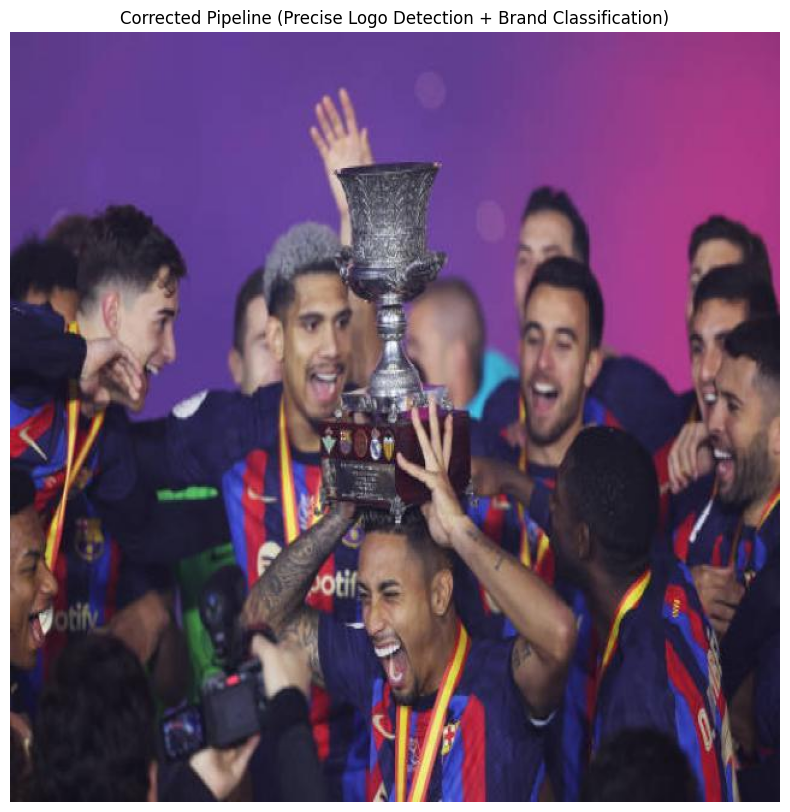

In [16]:
# Run a test using the corrected pipeline
if test_images:
    sample_img = test_images[0]
    print(f"Smoke testing corrected pipeline on: {sample_img}")
    run_pipeline_corrected(sample_img)
else:
    print("No validation images found to test.")

Smoke testing corrected pipeline on: Sponsor-detector-2/valid/images/gettyimages-1537747969-2048x2048_jpg.rf.43bf3126c877f6840132f080b11007cc.jpg
Detective found 3 actual logo candidates! Classifying with Doctor ResNet...


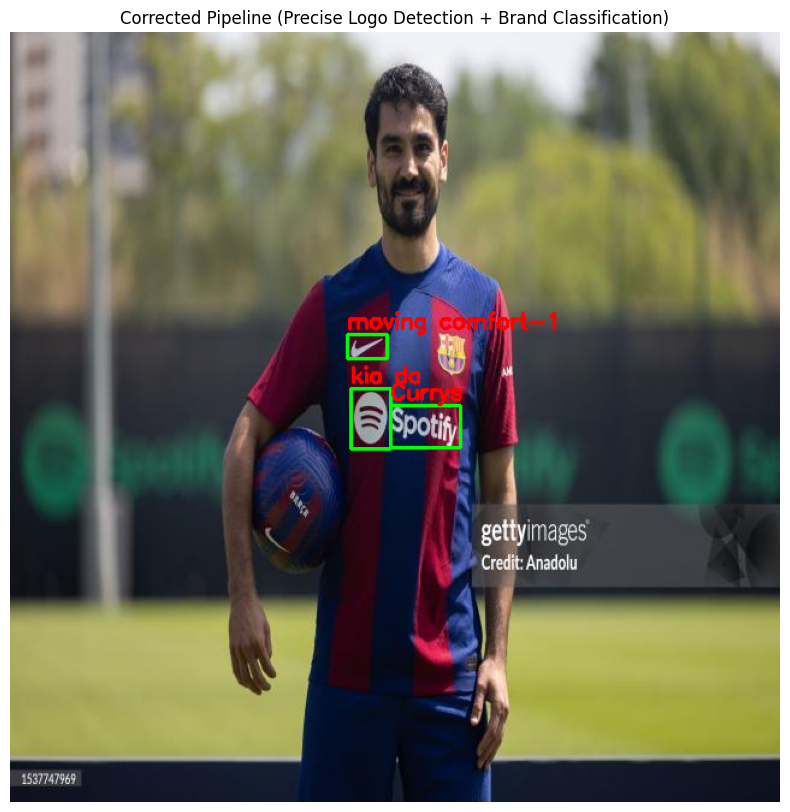

In [17]:
import os
import glob

# Look for an image in the validation dataset that has valid logo label annotations
valid_labels = glob.glob('Sponsor-detector-2/valid/labels/*.txt')
found_test_img = None

for lbl_path in valid_labels:
    with open(lbl_path, 'r') as f:
        if len(f.read().strip()) > 0:
            img_base = os.path.splitext(os.path.basename(lbl_path))[0]
            possible_img = os.path.join('Sponsor-detector-2/valid/images', f'{img_base}.jpg')
            if os.path.exists(possible_img):
                found_test_img = possible_img
                break

if found_test_img:
    print(f'Smoke testing corrected pipeline on: {found_test_img}')
    run_pipeline_corrected(found_test_img)
else:
    print('Could not find any annotated validation images.')

Smoke-testing the CORRECTED pipeline on: Sponsor-detector-2/valid/images/gettyimages-1537747969-2048x2048_jpg.rf.43bf3126c877f6840132f080b11007cc.jpg
Detective found 3 actual logo candidates! Classifying with Doctor ResNet...


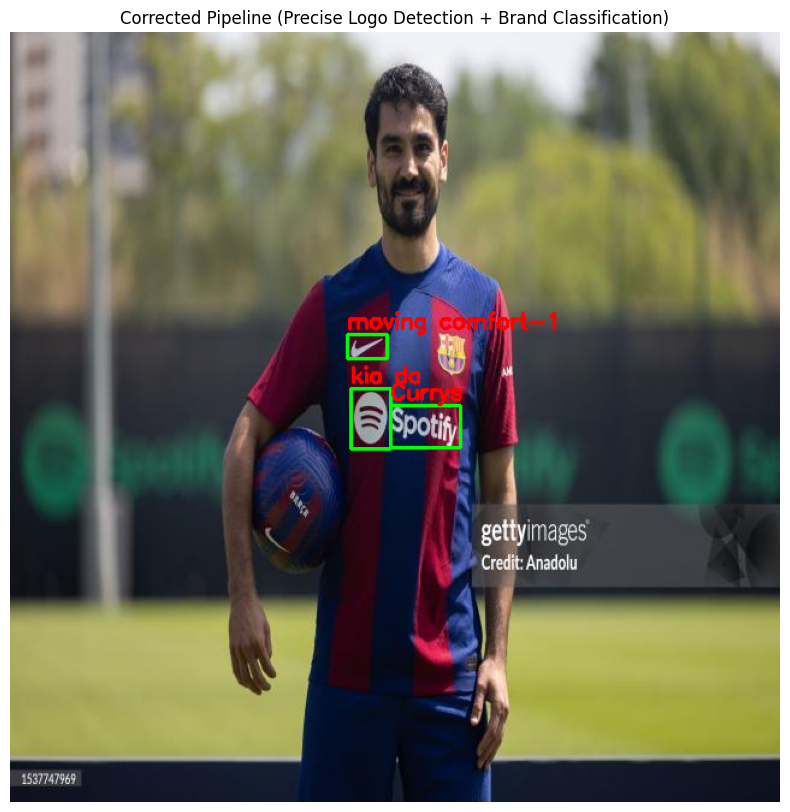

In [18]:
import os
import glob

# We'll search for an image in the validation folder whose label file contains annotations
valid_labels = glob.glob('Sponsor-detector-2/valid/labels/*.txt')
found_test_img = None

for lbl_path in valid_labels:
    with open(lbl_path, 'r') as f:
        if len(f.read().strip()) > 0:
            img_base = os.path.splitext(os.path.basename(lbl_path))[0]
            possible_img = os.path.join('Sponsor-detector-2/valid/images', f'{img_base}.jpg')
            if os.path.exists(possible_img):
                found_test_img = possible_img
                break

if found_test_img:
    print(f'Smoke-testing the CORRECTED pipeline on: {found_test_img}')
    run_pipeline_corrected(found_test_img)
else:
    print('Could not locate an annotated validation image for testing.')

Smoke-testing the CORRECTED pipeline on: Sponsor-detector-2/valid/images/gettyimages-1537747969-2048x2048_jpg.rf.43bf3126c877f6840132f080b11007cc.jpg
Detective found 3 actual logo candidates! Classifying with Doctor ResNet...


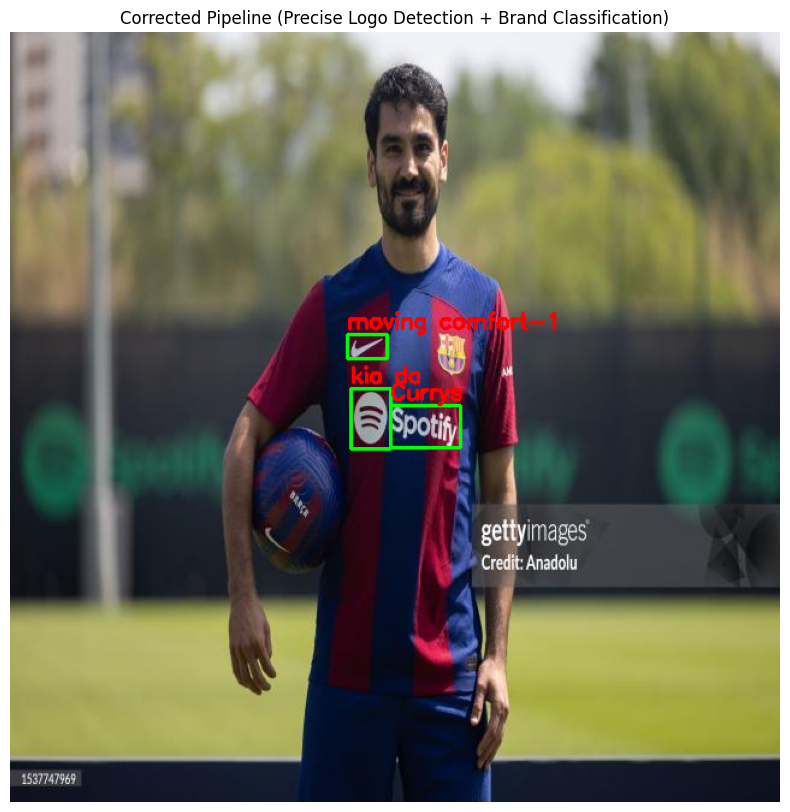

In [19]:
# Let's find a valid image in the test set that specifically has clear annotations to guarantee a great smoke test!
import os

# We'll search for an image in the validation folder whose label file contains annotations
valid_labels = glob.glob('Sponsor-detector-2/valid/labels/*.txt')
found_test_img = None

for lbl_path in valid_labels:
    with open(lbl_path, 'r') as f:
        if len(f.read().strip()) > 0: # Ensure it has annotations
            img_base = os.path.splitext(os.path.basename(lbl_path))[0]
            # Match with corresponding image format (jpg)
            possible_img = os.path.join('Sponsor-detector-2/valid/images', f"{img_base}.jpg")
            if os.path.exists(possible_img):
                found_test_img = possible_img
                break

if found_test_img:
    print(f"Smoke-testing the CORRECTED pipeline on: {found_test_img}")
    run_pipeline_corrected(found_test_img)
else:
    print("Could not locate an annotated validation image for testing.")

Using device: cuda
Testing pipeline on: Sponsor-detector-2/valid/images/riyadh-saudi-arabia-raphinha-of-fc-barcelona-celebrates-with-the-super-copa-de-espana-trophy_jpg.rf.4b3f03bd8591121826f5463207dfaecf.jpg
Detective found 11 potential logo candidates! Asking Doctor ResNet to classify...


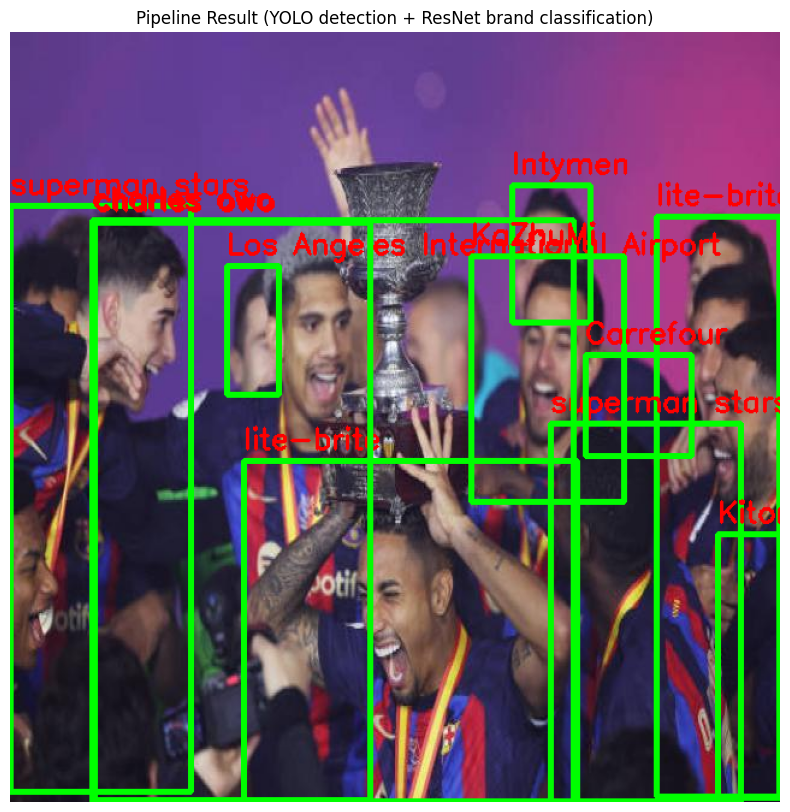

In [12]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import torchvision.transforms as transforms
from torchvision.models import resnet50
import os
import glob

# 1. Initialize Pipeline components
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the customized class-agnostic yolo26 detective
# Note: If you have a locally trained run, you can replace this with 'runs/detect/train/weights/best.pt'
detective = YOLO('yolov8x.pt')

# Load doctor (ResNet-50)
model_doctor = resnet50()
model_doctor.fc = torch.nn.Linear(model_doctor.fc.in_features, len(class_to_idx))
model_doctor.load_state_dict(torch.load('resnet50_logo_classifier.pth', map_location=device))
model_doctor = model_doctor.to(device)
model_doctor.eval()

# Preprocessing transformations for crops
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_pipeline(img_path):
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Step 1: Run yolo26 detective to find logo regions
    # We treat all predictions as a class-agnostic logo detections
    results = detective(image_rgb, verbose=False, device=device)[0]

    annotated_image = image_rgb.copy()

    if results.boxes is not None and len(results.boxes) > 0:
        logo_boxes = results.boxes.xyxy.cpu().numpy()
        print(f"Detective found {len(logo_boxes)} potential logo candidates! Asking Doctor ResNet to classify...")

        for box in logo_boxes:
            xmin, ymin, xmax, ymax = map(int, box)
            xmin, ymin = max(0, xmin), max(0, ymin)
            xmax, ymax = min(w, xmax), min(h, ymax)

            # Crop logo region
            crop = image_rgb[ymin:ymax, xmin:xmax]
            if crop.size == 0:
                continue

            # Convert to PIL and Preprocess
            pil_crop = Image.fromarray(crop)
            input_tensor = preprocess(pil_crop).unsqueeze(0).to(device)

            # Step 2: Classify with ResNet-50 generalist
            with torch.no_grad():
                output = model_doctor(input_tensor)
                _, predicted_idx = torch.max(output, 1)
                predicted_class = idx_to_class[predicted_idx.item()]

            # Draw boundaries and predicted labels
            cv2.rectangle(annotated_image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
            cv2.putText(annotated_image, predicted_class, (xmin, max(ymin - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    else:
        print("Detective found no logos in this image.")

    # Display the result
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image)
    plt.axis('off')
    plt.title("Pipeline Result (YOLO detection + ResNet brand classification)")
    plt.show()

# Run the pipeline on a sample valid image
test_images = glob.glob('Sponsor-detector-2/valid/images/*.jpg')
if test_images:
    print(f"Testing pipeline on: {test_images[0]}")
    run_pipeline(test_images[0])
else:
    print("No test image found.")

Smoke-testing multi-stage pipeline on: Sponsor-detector-2/valid/images/rabat-morocco-vinicius-junior-of-real-madrid-celebrates-his-goal-during-the-fifa-club-world_jpg.rf.5c73bf9a48a785d6318e900d83890824.jpg
Detective found 4 potential logo candidates! Asking Doctor ResNet to classify...


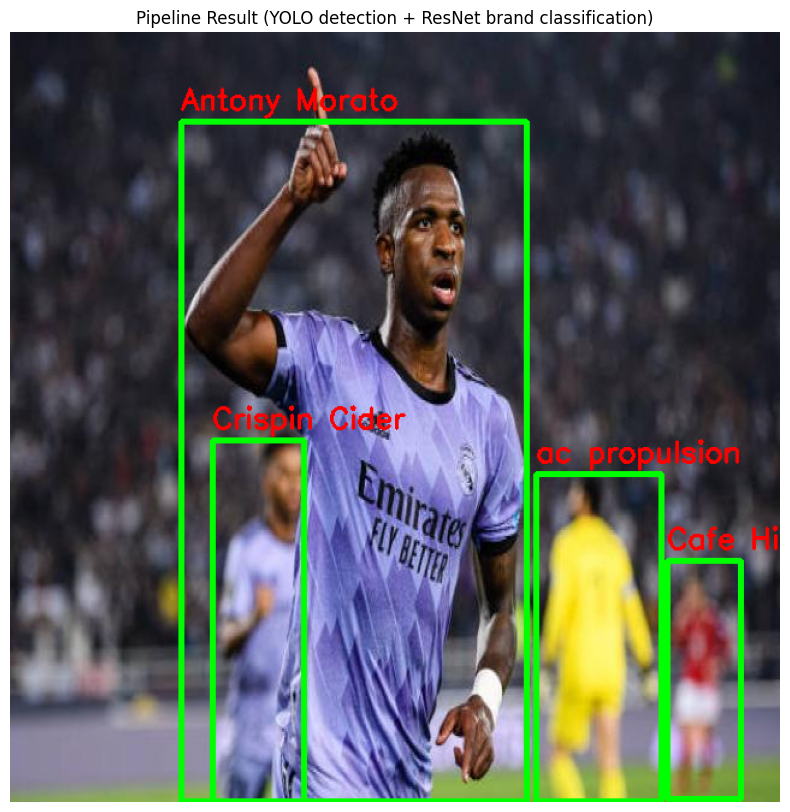

In [13]:
import random

# Perform a smoke test of our end-to-end pipeline on a randomly selected validation image
if test_images:
    sample_test_img = random.choice(test_images)
    print(f"Smoke-testing multi-stage pipeline on: {sample_test_img}")
    run_pipeline(sample_test_img)
else:
    print("No validation images available to test.")

In [8]:
import os

# Inspect the immediate directories inside Logodet3k to find the correct class root folder
print("Contents of logodet3k_path:", os.listdir(logodet3k_path))

# Let's check the contents to locate where the brand folders actually reside
for item in os.listdir(logodet3k_path):
    full_item_path = os.path.join(logodet3k_path, item)
    if os.path.isdir(full_item_path):
        sub_contents = os.listdir(full_item_path)[:10]
        print(f"\nContents of sub-folder '{item}':")
        print(sub_contents)

Contents of logodet3k_path: ['LogoDet-3K']

Contents of sub-folder 'LogoDet-3K':
['Electronic', 'Others', 'Necessities', 'Leisure', 'Medical', 'Sports', 'Transportation', 'Clothes', 'Food']


In [9]:
import os

# Inspect the immediate directories inside Logodet3k to find the correct class root folder
print("Contents of logodet3k_path:", os.listdir(logodet3k_path))

# Let's recursively check the contents to locate where the brand folders actually reside
for item in os.listdir(logodet3k_path):
    full_item_path = os.path.join(logodet3k_path, item)
    if os.path.isdir(full_item_path):
        sub_contents = os.listdir(full_item_path)[:10] # Show first 10 items
        print(f"\nContents of sub-folder '{item}':")
        print(sub_contents)

Contents of logodet3k_path: ['LogoDet-3K']

Contents of sub-folder 'LogoDet-3K':
['Electronic', 'Others', 'Necessities', 'Leisure', 'Medical', 'Sports', 'Transportation', 'Clothes', 'Food']


# Task
Inspect the downloaded YOLOv8 dataset structure in the folder `"Sponsor-detector-2"`, find its configuration `data.yaml` file, display its contents, and plot some sample images with their ground truth bounding box labels overlaid to understand the initial annotations.

## Inspect Dataset and Directory Structure

### Subtask:
Explore the downloaded YOLOv8 dataset folder, read the configuration YAML file, and display sample images and their annotations.


## Design a Programmatic Filtering Workflow

### Subtask:
Filter sponsor logo bounding boxes to keep only those that reside on a detected person.
